# Modelos

**Nota: En este notebook trabajaremos con los datos del dataset fdrec, pero clasificados. Es decir, se utilizará una feature adicional que contiene la clase asignada a cada muestra: iron o proton.**

Este notebook está diseñado para contener todos los modelos que se emplearán con el objetivo de predecir el tipo de partícula (hierro o protón) asociada al rayo cósmico analizado. A lo largo del notebook, se llevará a cabo el siguiente flujo de trabajo:

Preparación de los datos: Incluye limpieza(Seleccion de las feactures mas adecuadas), codificación de variables y división en conjuntos de entrenamiento y prueba.

Entrenamiento de modelos: Se probarán distintos algoritmos de clasificación para evaluar cuál ofrece el mejor desempeño.

Evaluación de métricas: Se analizarán distintas métricas (como precisión, recall, F1-score, etc.) para comparar objetivamente los modelos.

Selección del mejor modelo: Según los resultados, se elegirá el modelo más adecuado para futuras predicciones.

Ahora, antes de comenzar con el preprocesamiento, echemos un vistazo a los datos con los que vamos a trabajar.


## Librerías a usar


Para poder llevar a cabo este trabajo, utilizaremos un conjunto de librerías fundamentales tanto para la manipulación de datos como para la construcción, entrenamiento y evaluación de modelos de clasificación. Además, emplearemos herramientas para la visualización de resultados de manera clara y efectiva.

Las principales librerías que se utilizarán son:

**Pandas:** Para la carga, exploración y manipulación de datos tabulares.

**Scikit-learn**: Para la implementación de modelos de Machine Learning, así como para el preprocesamiento, evaluación y validación cruzada.

**Matplotlib**: Para la creación de gráficos y visualizaciones que nos ayuden a interpretar los resultados obtenidos.

Opcionalmente, podríamos complementar este conjunto con otras librerías como:

**Seaborn**: Para generar visualizaciones más detalladas y estilizadas.

**NumPy**: Para operaciones matemáticas de bajo nivel, especialmente en el manejo de arreglos y matrices.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from collections import Counter

In [2]:
fdrec_clasificado=pd.read_csv("fdrec_clasificados.csv")
fdrec_clasificado.head()

,id,gpsnanotime,hdSpectrumEye,hdCalibEye,hdXmaxEye,theta,dtheta,phi,dphi,l,...,cherenkovFraction,minViewAngle,uspL,duspL,uspR,duspR,hottestStationId,distSdpStation,distAxisStation,particle_type
0,1,257161602,0,0,1,48.21,0.38,157.74,0.66,190.73,...,0.08,63.34,229.80,9.60,0.26,0.05,310,54.05,711.71,iron
1,4,278779315,0,0,1,46.34,0.45,255.79,0.68,300.22,...,0.10,31.97,220.66,8.71,0.25,0.05,658,130.63,163.89,iron
2,1,901642884,0,0,1,27.71,0.74,349.57,1.31,244.14,...,0.08,47.52,233.85,8.93,0.25,0.04,246,31.26,608.84,iron
3,1,814732146,0,0,1,45.88,0.40,118.58,0.53,177.78,...,0.11,33.29,231.96,6.35,0.23,0.04,308,285.74,312.06,iron
4,4,166608618,0,0,1,23.81,0.42,34.96,0.99,233.00,...,0.11,44.82,232.43,10.05,0.26,0.05,643,599.18,599.26,iron


## variables seleccionadas 
Ahora bien el modelo no vamos a trabajarlo con todos las columnas, o caracteristicas de las muestras, ya que estas como lo demostramos en el eda, tienen poca correlacion con la variable objectivo, y al tener poca correlacion conlleva que a la hora de hacer el modelo estas caracterisiticas traigan consigo ruido para el modelo, lo que termina siendo mas problematico a la hora de tratar de solucionar el problema.

In [3]:
fdrec_clasificado=fdrec_clasificado[["theta","phi","dec","totalEnergy","dtotalEnergy","calEnergy","dcalEnergy","xmax"
                        ,"heightXmax","dEdXmax","particle_type","dxmax"]]

In [4]:
fdrec_clasificado.dtypes

theta            float64
phi              float64
dec              float64
totalEnergy      float64
dtotalEnergy     float64
calEnergy        float64
dcalEnergy       float64
xmax             float64
heightXmax       float64
dEdXmax          float64
particle_type     object
dxmax            float64
dtype: object

In [5]:
Cantidad_proton=len(fdrec_clasificado.loc[fdrec_clasificado["particle_type"]=="proton"])
cantidad_iron=len(fdrec_clasificado.loc[fdrec_clasificado["particle_type"]=="iron"])
print(f"la cantidad de datos pertenecientes a un proton es {Cantidad_proton} y la cantidad de registros pertenecientes a un iron es {cantidad_iron}")

la cantidad de datos pertenecientes a un proton es 671 y la cantidad de registros pertenecientes a un iron es 2716


## Análisis preliminar

A partir de las tres celdas de código anteriores, podemos destacar varios aspectos importantes que debemos tener en cuenta para abordar adecuadamente el problema:

1. **Tipo de problema**: Nos encontramos ante un problema de clasificación binaria, donde las clases posibles son "proton" e "iron".

2. **Tipo de datos**: Todas las columnas del DataFrame contienen datos numéricos, excepto la columna particle_type, que representa la clase de cada muestra y contiene valores de tipo object (texto). Esta columna será nuestro objetivo (target) en la tarea de clasificación.

3. **Desbalance de clases**: Un punto crítico a considerar es que estamos frente a un caso de clases desbalanceadas, es decir, existe una cantidad significativamente mayor de muestras para una clase en comparación con la otra. Este desbalance puede llevar a que un modelo entrenado sin correcciones tienda a predecir únicamente la clase mayoritaria, ignorando por completo la minoritaria. Esto compromete la calidad del modelo, especialmente si el objetivo es detectar correctamente ambas clases.

Para abordar este problema, podemos aplicar alguna de las siguientes estrategias:

* Oversampling (aumento de datos): Generar nuevas muestras sintéticas de la clase minoritaria (por ejemplo, utilizando técnicas como SMOTE) para equilibrar el conjunto de datos.

* Undersampling (reducción de datos): Eliminar muestras de la clase mayoritaria para que ambas clases tengan un número similar de ejemplos.

* Uso de técnicas específicas en los modelos: Algunos algoritmos permiten ajustar el parámetro de pesos para penalizar más los errores en la clase minoritaria.

Teniendo en cuenta estas consideraciones, el siguiente paso será preparar los datos para la fase de entrenamiento. Esto incluye la codificación de la variable objetivo, el escalado de las características si es necesario, y la división del conjunto en datos de entrenamiento y prueba.

In [6]:
le = LabelEncoder()
y = le.fit_transform(fdrec_clasificado["particle_type"])  # convierte a números

# Separar características (X) y usar la nueva y numérica
X = fdrec_clasificado.drop("particle_type", axis=1)

# División estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
label_mapping = {label: idx for idx, label in enumerate(le.classes_)}
print("Diccionario de clases:", label_mapping)




Diccionario de clases: {'iron': 0, 'proton': 1}


In [7]:
Counter(y_train)

Counter({0: 2172, 1: 537})

## Modelos seleccionados


Una vez separados los datos en conjuntos de entrenamiento y prueba, pasamos a la selección de modelos de clasificación. Esta elección debe considerar las características del problema, como: se trata de un problema de clasificación binaria, los datos contienen únicamente variables numéricas, Existe un desbalance en las clases, lo que puede afectar el rendimiento de los modelos si no se maneja correctamente.

Ahora, presentamos los modelos seleccionados y una breve explicación de por qué son adecuados para este caso, junto con sus principales ventajas:

**Árbol de Decisión**: Aunque este modelo no es presisamente el mas adecuado para dar solucion a problemas de este tipo, donde las clases estan muy desbalanceada este modelo lo vamos a tener en cuenta para ver este modelo sencillo que tanta importancia le da a cada caracteristica y asi poder tener una idea inicial y ademas de esto como es un modelo base para los demas modelos entonces podemos tomar la grafica del modelo de decicion que este crea y asi visualizar la importancia de cada variable y que tanto los datos varian de clase o que tanto tienende el modelo de llevar a los datos a tomar decision por caracteristicas muy expesificas.

**Random Forest** :
Random Forest es un modelo de ensamble que combina múltiples árboles de decisión entrenados sobre subconjuntos aleatorios del conjunto de datos, lo que mejora la capacidad de generalización y reduce el riesgo de sobreajuste. Una de sus principales ventajas en este contexto es que puede manejar de forma eficaz los problemas de desbalanceo de clases mediante el parámetro class_weight='balanced', que ajusta los pesos de las clases en función de su frecuencia. Esto permite que el modelo no se sesgue hacia la clase mayoritaria sin necesidad de alterar directamente el dataset. Además, Random Forest es robusto frente a valores atípicos y ruido, y suele ofrecer un mejor rendimiento que un árbol de decisión individual, manteniendo un buen equilibrio entre precisión e interpretabilidad.

**XGBoost (con escala de pesos)** :
XGBoost es un potente algoritmo de boosting que entrena modelos secuenciales donde cada uno corrige los errores del anterior, logrando así un aprendizaje más preciso. Es especialmente eficaz en problemas de clasificación desbalanceada gracias al parámetro scale_pos_weight, que permite darle mayor importancia a la clase minoritaria durante el entrenamiento. Este modelo incluye regularización para evitar el sobreajuste, ofrece un rendimiento computacional muy alto al permitir paralelización y, cuando se ajustan correctamente sus hiperparámetros, puede superar fácilmente a otros modelos como Random Forest. Por estas razones, XGBoost es considerado uno de los algoritmos más potentes y eficientes en tareas de clasificación del mundo real.



### Arbol de decicion

In [8]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import plot_tree
# Crear el modelo con ajuste al desbalance
tree_clf = DecisionTreeClassifier(
    class_weight='balanced',  # compensa el desbalance
    random_state=42,
    max_depth=3, 
    max_features=None,
    min_samples_split=2,
    min_samples_leaf=5,
    criterion="gini"   
)
# Entrenar
tree_clf.fit(X_train, y_train)

# Predecir
y_pred = tree_clf.predict(X_test)


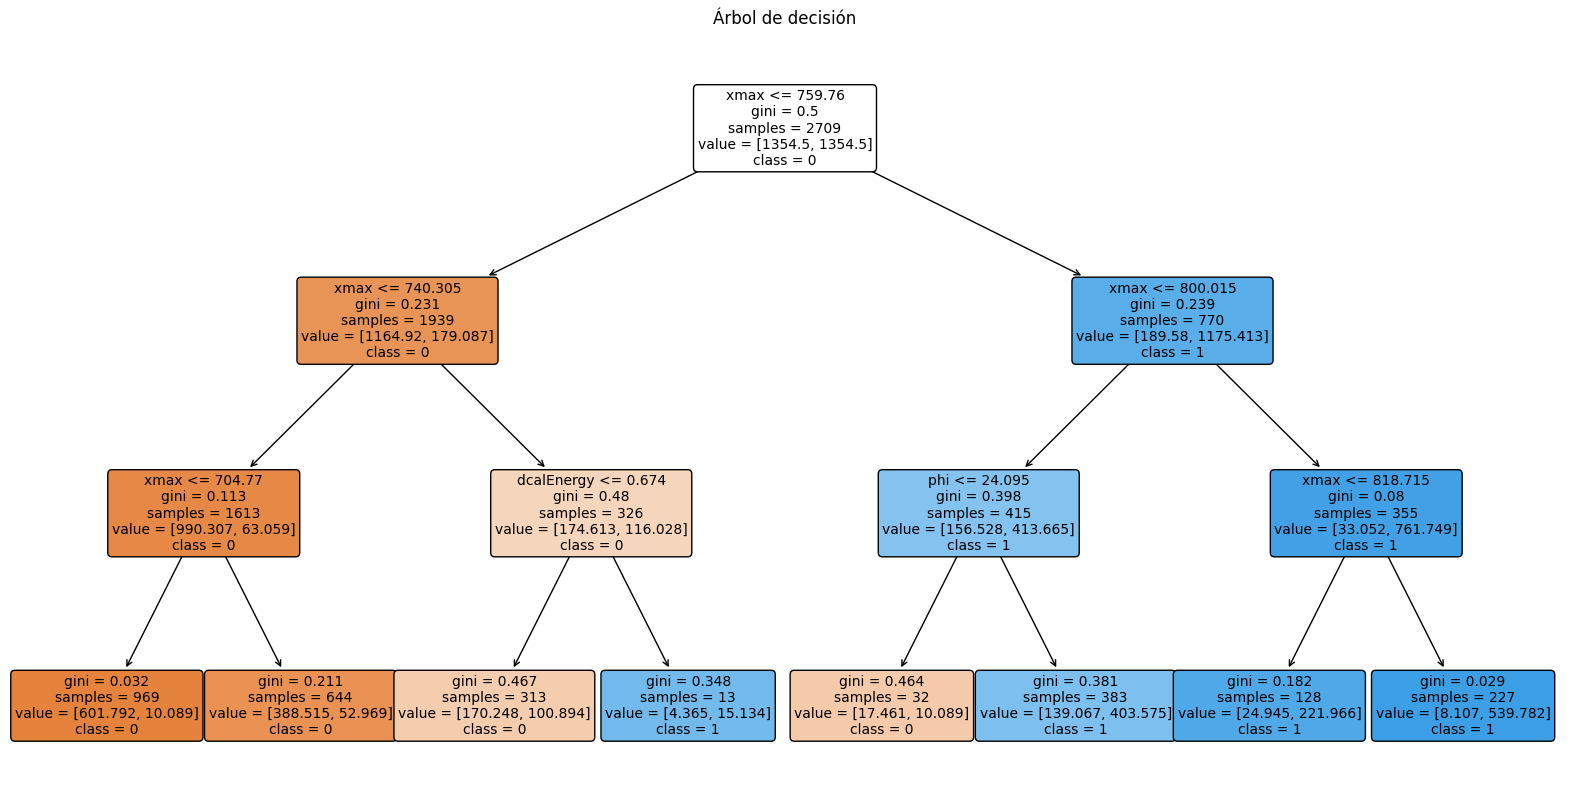

In [9]:
plt.figure(figsize=(20, 10))  # Tamaño ajustable
plot_tree(tree_clf,
            feature_names=X_train.columns,
            class_names=tree_clf.classes_.astype(str),
            filled=True,
            rounded=True,
            fontsize=10)
plt.title("Árbol de decisión")
plt.savefig("images/treedecision_image.png")
plt.show()


Este árbol de decisión fue entrenado para clasificar partículas (por ejemplo, protones e iones) en dos clases balanceadas, usando variables como xmax, dcalEnergy y phi. El árbol comienza con una división basada en xmax, lo que ya permite una buena separación: valores menores o iguales a 759.76 tienden a pertenecer a la clase 0, mientras que valores superiores a esa cifra están mayoritariamente en la clase 1. A medida que se desciende por el árbol, las divisiones adicionales afinan la clasificación, alcanzando nodos con impureza muy baja (gini cercano a 0), lo que indica alta confianza en las predicciones.

Por ejemplo, cuando xmax > 818.715, el modelo clasifica casi con certeza como clase 1, mientras que valores bajos de xmax y dcalEnergy, como también ciertas condiciones en phi, ayudan a reforzar la predicción hacia la clase 0 o ajustar decisiones más dudosas. En general, el árbol muestra reglas claras, buen poder de separación con pocas variables y varias hojas muy puras, lo que lo hace interpretativo y efectivo para diferenciar entre las clases del problema.

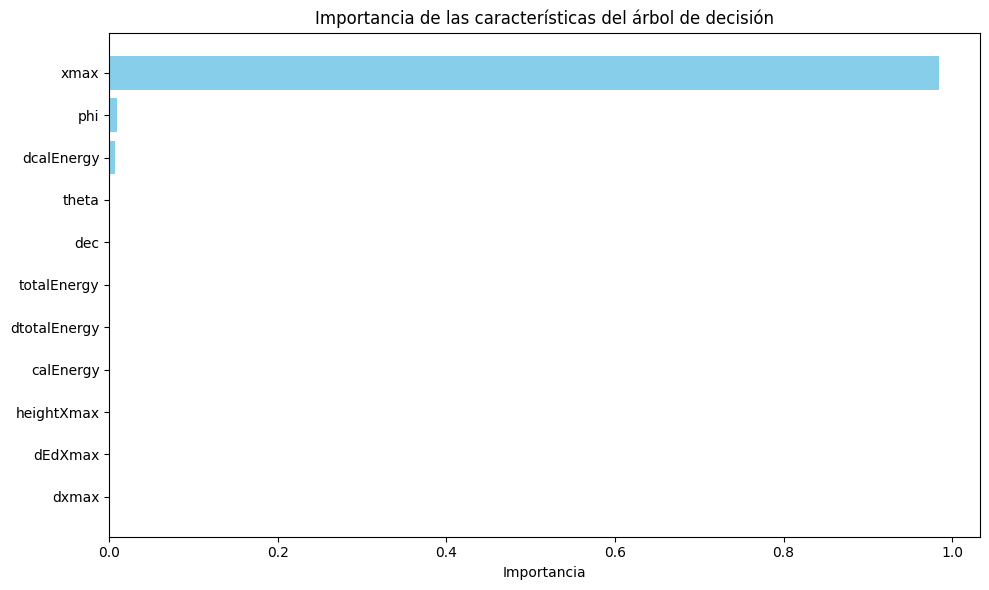

In [10]:
# Obtener las importancias
importances = tree_clf.feature_importances_

# Si X_train es un DataFrame, tomamos los nombres de las columnas
feature_names = X_train.columns

# Crear un DataFrame con las importancias
feat_importances = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# Graficar
plt.figure(figsize=(10, 6))
plt.barh(feat_importances['feature'], feat_importances['importance'], color='skyblue')
plt.gca().invert_yaxis()  # Para que las más importantes salgan arriba
plt.xlabel('Importancia')
plt.title('Importancia de las características del árbol de decisión')
plt.tight_layout()
plt.savefig("images/labelImportance_decisionTree.png")
plt.show()

Ahora bien, aquí podemos observar cuáles son las características (features) que el modelo considera más importantes. De hecho, esto es una señal negativa, ya que el modelo está dando importancia únicamente a tres variables. Además, la variable xmax es, por mucho, la más influyente en la toma de decisiones del modelo, superando ampliamente a las demás. Esta desproporción puede deberse, en parte, a que la asignación de la variable objetivo (target) se realizó de forma muy manual, lo que ha generado un sesgo considerable en el modelo.

In [11]:
# Evaluar
train_pred = tree_clf.predict(X_train)
print("Matriz de confusión conjunto entrenamiento:")
confusion_matrix(y_train, train_pred)

Matriz de confusión conjunto entrenamiento:


array([[1889,  283],
       [  69,  468]], dtype=int64)

In [12]:
print("Matriz de confusión conjunto testeo:")
confusion_matrix(y_test, y_pred)

Matriz de confusión conjunto testeo:


array([[458,  86],
       [ 25, 109]], dtype=int64)

In [13]:
print("\nReporte de clasificación conjunto prueba :")
print(classification_report(y_test, y_pred))


Reporte de clasificación conjunto prueba :
              precision    recall  f1-score   support

           0       0.95      0.84      0.89       544
           1       0.56      0.81      0.66       134

    accuracy                           0.84       678
   macro avg       0.75      0.83      0.78       678
weighted avg       0.87      0.84      0.85       678



Ahora analicemos las métricas obtenidas. Primero que todo, comenzamos revisando la matriz de confusión. Esta matriz nos indica que el modelo está generando muchos falsos positivos, es decir, está clasificando incorrectamente muchos datos de la clase 0 como si fueran de la clase 1, que en este caso corresponde a protones. Sin embargo, esto en cierto punto es esperable, ya que al estar el conjunto de datos desbalanceado, el modelo no aprende correctamente la clase minoritaria.

Esto también se refleja cuando evaluamos la precisión. Para la clase hierro, la precisión es del 95 %, lo cual tiene sentido porque la mayoría de las muestras pertenecen a esta clase. De hecho, incluso si el modelo predijera que todos los casos son hierro, la precisión seguiría siendo alta simplemente por el desbalance.

Por otro lado, al analizar la "otra cara de la moneda", que sería la clasificación de los protones, la precisión cae a casi un 50 %, lo que sugiere que el modelo está prediciendo esta clase casi al azar. Sin embargo, si observamos el recall para los protones, vemos que es de casi un 81 %, lo cual es bastante alto. Esto nos indica que el modelo está logrando encontrar muchos casos positivos, pero probablemente lo está haciendo basándose en características poco representativas o específicas de ciertas muestras. Esto es problemático, porque además de tener pocas muestras de protones, el modelo termina clasificando por particularidades poco generalizables, lo que puede generar un fuerte sesgo.

Una vez sacada las conclusiones sobre este primer modelo exploratorio vamos a analizar otros modelos que en teoria estan basados en este modelo, pero son mas potentes y efectivos a la hora de enfrentarse a modelos que son desvalanceados.

### Random forest

Ahora bien, como mencionamos anteriormente, el Random Forest es muy bueno para trabajar con conjuntos de datos desbalanceados. Aunque su modelo base es un árbol de decisión —el cual por sí solo puede ser muy sensible al desbalance—, Random Forest mejora este aspecto al construir una gran cantidad de árboles y combinar sus predicciones. Esto ayuda a reducir problemas como el sobreajuste, ya que el modelo se beneficia de la diversidad de árboles generados a partir de diferentes subconjuntos del conjunto de entrenamiento.

Además, si utilizamos técnicas adicionales como la ponderación de clases (class_weight) o el muestreo equilibrado (balanced subsampling), podemos hacer que el Random Forest sea aún menos susceptible a los efectos negativos del desbalance. Estas estrategias obligan al modelo a prestar más atención a las clases minoritarias, mejorando así la capacidad de generalización y reduciendo los falsos negativos o falsos positivos en esas clases. Por lo tanto, el uso adecuado de Random Forest junto con técnicas de balanceo puede ser una solución efectiva para este tipo de problemas.

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix

In [15]:
# Definir el modelo base
rf_base = RandomForestClassifier(class_weight='balanced', random_state=42)

# Definir el grid de hiperparámetros a probar
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 3 , 7, 10,20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

# Configurar la búsqueda con validación cruzada
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5,
    scoring='f1_macro',  # buena métrica para desbalance
    n_jobs=-1,
    verbose=2
)

# Entrenar para encontrar los mejores hiperparámetros
grid_search.fit(X_train, y_train)

# Mostrar mejores parámetros encontrados
print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)

# Evaluar el mejor modelo
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)

Fitting 5 folds for each of 135 candidates, totalling 675 fits


Mejores hiperparámetros encontrados:
{'max_depth': None, 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}


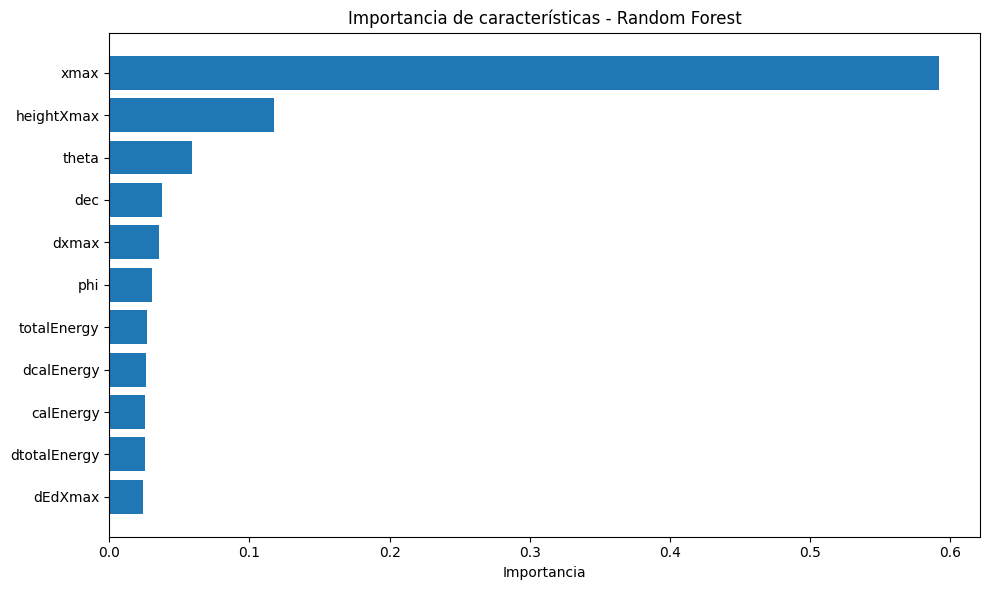

In [16]:
# Supongamos que tienes un DataFrame con nombres de columnas
feature_names = X_train.columns  # Si X_train es un DataFrame

# Obtener importancia de cada feature
importances = best_rf.feature_importances_

# Crear un DataFrame ordenado
feat_importances = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feat_importances['Feature'], feat_importances['Importance'])
plt.gca().invert_yaxis()  # Opcional: pone la más importante arriba
plt.title('Importancia de características - Random Forest')
plt.xlabel('Importancia')
plt.tight_layout()
plt.savefig("images/labelImportance_randomForest.png")
plt.show()


Una vez entrenado el modelo, podemos apreciar que nuestro Random Forest ahora es capaz de asignar importancia a todas las features, a diferencia del modelo anterior (el árbol de decisión simple), que solo consideraba tres variables para tomar decisiones. Esto representa una mejora significativa en cuanto a la capacidad del modelo para aprender patrones más complejos, ya que toma en cuenta una mayor variedad de características.

Sin embargo, aunque este modelo distribuye la importancia entre más variables, aún persiste una concentración de peso en tres features principales. Esto sugiere que, si bien el modelo considera más datos, sigue dependiendo fuertemente de ciertas variables. Esta situación puede derivar en sobreajuste (overfitting) si el modelo se adapta demasiado a las particularidades del conjunto de entrenamiento, o subajuste (underfitting) si ignora patrones relevantes por priorizar solo unas pocas características dominantes. Por lo tanto, es fundamental evaluar el rendimiento del modelo en datos no vistos para validar su capacidad de generalización, y, si es necesario, aplicar técnicas adicionales como la selección de variables, regularización o ensamblado con otros modelos.

In [17]:
# Evaluar el modelo
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))


Matriz de confusión:
[[493  51]
 [ 35  99]]


In [18]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.93      0.91      0.92       544
           1       0.66      0.74      0.70       134

    accuracy                           0.87       678
   macro avg       0.80      0.82      0.81       678
weighted avg       0.88      0.87      0.88       678



Ahora, en el análisis de las métricas de evaluación, podemos observar que en general la mayoría de los resultados han mejorado con respecto al modelo anterior. En primer lugar, notamos un incremento en la precisión para detectar la clase minoritaria, que ahora alcanza un 66%. Esto indica que el modelo es más capaz de identificar correctamente los ejemplos de esa clase, lo cual es especialmente valioso en contextos de clasificación desbalanceada.

Además, también se observa una ligera disminución en la precisión de la clase mayoritaria, lo cual puede parecer negativo a primera vista, pero en realidad es una señal de que el modelo está generalizando mejor. Al no centrarse únicamente en la clase dominante (como ocurría antes), se reduce el riesgo de sobreajuste y se mejora el rendimiento en conjuntos de datos nuevos o no vistos.

Al observar el recall, los resultados son alentadores: el modelo logra identificar correctamente aproximadamente el 70% de los datos de la clase minoritaria. Esta mejora se refleja también en la métrica F1-score, que equilibra precisión y recall, ofreciendo una visión más completa del rendimiento del modelo en un escenario desbalanceado.

No obstante, aunque los resultados han mejorado significativamente, aún hay margen para optimizar. Para seguir perfeccionando el rendimiento, podemos explorar el uso de modelos más especializados, como XGBoost o LightGBM, así como la aplicación de técnicas de reesampling (oversampling o undersampling) o generación sintética de datos (como SMOTE), que ayudarán a balancear mejor las clases y permitirán al modelo aprender de forma más robusta.

### XGBoost

XGBoost es un modelo muy potente porque aprende de sus errores: en lugar de construir muchos árboles al azar como hace Random Forest, XGBoost entrena árboles uno tras otro, y cada nuevo árbol intenta corregir los errores que cometieron los anteriores. Esto le da una gran capacidad para mejorar poco a poco y alcanzar muy buenos resultados, especialmente cuando se ajustan bien sus parámetros. Además, es rápido, eficiente, maneja bien los valores faltantes, y tiene mecanismos que evitan que se sobreentrene, lo cual es clave para obtener modelos que funcionen bien con datos reales.

Una de las razones por las que XGBoost es tan útil en problemas con clases desbalanceadas es que tiene una opción para ajustar automáticamente la importancia de las clases menos representadas. Por ejemplo, si en tu conjunto de datos tienes muy pocos casos positivos (como en enfermedades raras o fraudes), XGBoost puede darles más peso para que el modelo no los ignore. Esto es muy beneficioso porque evita que el modelo se limite a predecir siempre la clase mayoritaria, y ayuda a detectar mejor los casos que realmente nos interesan, aunque sean pocos.

In [19]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from scipy.stats import uniform, randint
import xgboost as xgb

In [20]:
# Calcular scale_pos_weight para datos desbalanceados
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# Definir el clasificador
xgb_clf = XGBClassifier(
    objective='binary:logistic',
    scale_pos_weight=scale_pos_weight,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

# Definir el espacio de búsqueda
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 15),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'reg_lambda': uniform(0, 5),
    'reg_alpha': uniform(0, 5)
}

# Búsqueda aleatoria con validación cruzada
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1',  # o puedes usar 'recall', 'roc_auc', etc.
    cv=3,
    verbose=1,
    n_jobs=-1,
    random_state=42
)

# Ajustar el modelo
random_search.fit(X_train, y_train)

# Mostrar mejores parámetros
print("Mejores parámetros encontrados:")
print(random_search.best_params_)

# Evaluar el mejor modelo
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)
train_predic=best_model.predict(X_train)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


c:\Users\David\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\core.py:158: UserWarning: [03:36:18] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Mejores parámetros encontrados:
{'colsample_bytree': 0.996884623716487, 'gamma': 3.0874075481385828, 'learning_rate': 0.19349594814648427, 'max_depth': 14, 'n_estimators': 138, 'reg_alpha': 1.4561457009902097, 'reg_lambda': 3.0592644736118975, 'subsample': 0.6557975442608167}


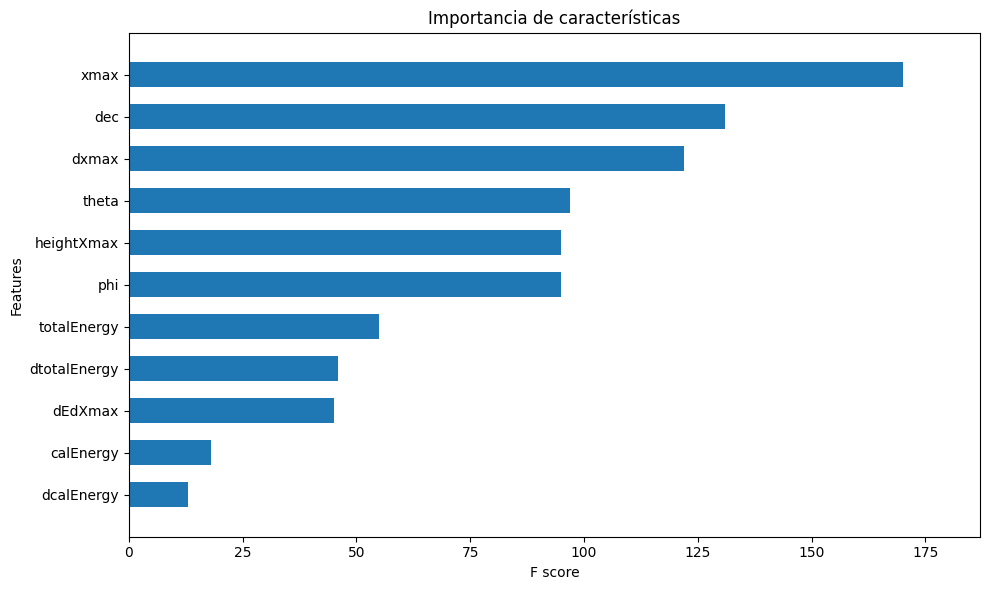

In [21]:
# Este método funciona directamente con XGBClassifier
import matplotlib.pyplot as plt
import xgboost as xgb

fig, ax = plt.subplots(figsize=(10, 6))

xgb.plot_importance(
    best_model,
    importance_type='weight',
    max_num_features=20,
    height=0.6,
    ax=ax,
    show_values=False, 
    grid=False          
)

plt.title("Importancia de características")
plt.tight_layout()
plt.savefig("images/labelImportance_XGBoost.png", dpi=300)
plt.show()


Ahora bien, como podemos observar, la diferencia en la importancia entre las distintas características ya no es tan marcada como en modelos anteriores. Esto indica que el modelo está considerando una mayor variedad de features para tomar decisiones, en lugar de depender únicamente de unas pocas variables predominantes. Este comportamiento es positivo, ya que al distribuir la importancia entre más características, se reduce el riesgo de sobreajuste, es decir, que el modelo se adapte demasiado a los datos de entrenamiento y no generalice bien a nuevos datos.

Además, tener un modelo que se basa en una gama más amplia de información permite que las decisiones que toma sean más robustas y equilibradas. Esto mejora la capacidad del modelo para adaptarse a distintos patrones y situaciones, haciendo que sus predicciones sean más confiables a largo plazo. En contextos reales, donde los datos pueden variar o cambiar con el tiempo, contar con un modelo que no depende de pocas variables críticas es una gran ventaja.

In [22]:
# Evaluar
print("Matriz de confusión entreno:")
print(confusion_matrix(y_train, train_predic))

Matriz de confusión entreno:
[[2025  147]
 [   9  528]]


In [23]:
# Evaluar
print("Matriz de confusión testeo:")
print(confusion_matrix(y_test, y_pred))

Matriz de confusión testeo:
[[482  62]
 [ 32 102]]


In [24]:
print("\nReporte de clasificación train:")
print(classification_report(y_train, train_predic))


Reporte de clasificación train:
              precision    recall  f1-score   support

           0       1.00      0.93      0.96      2172
           1       0.78      0.98      0.87       537

    accuracy                           0.94      2709
   macro avg       0.89      0.96      0.92      2709
weighted avg       0.95      0.94      0.94      2709



In [25]:
print("\nReporte de clasificación testep:")
print(classification_report(y_test, y_pred))


Reporte de clasificación testep:
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       544
           1       0.62      0.76      0.68       134

    accuracy                           0.86       678
   macro avg       0.78      0.82      0.80       678
weighted avg       0.88      0.86      0.87       678



 el modelo presenta un desempeño razonablemente bueno en la detección de la clase minoritaria dentro de un contexto de datos altamente desbalanceados. El recall de 0.76 indica que la mayoría de los casos positivos están siendo correctamente identificados, lo cual es crucial en escenarios donde la detección temprana o correcta de esta clase es prioritaria, como en fraude o diagnóstico médico. El F1-score de 0.68 también refleja un equilibrio aceptable entre precisión y recall, mostrando que el modelo no solo es sensible sino también relativamente preciso en sus predicciones para la clase minoritaria.

No obstante, existe un margen significativo para mejorar la equidad del modelo, especialmente en términos de precisión, que actualmente es de 0.62 para la clase minoritaria, sugiriendo una tasa notable de falsos positivos. 

## Tecnica de reajustes de los datos 
Una vez obtenidos los resultados, podemos observar que los modelos alcanzan métricas aceptables: presentan un buen índice de recall y un F1-score equilibrado. Cabe aclarar que, dado que estamos trabajando con un conjunto de datos desbalanceado, la precisión (precision) no se considera la métrica principal, ya que puede resultar engañosa en este tipo de problemas. En cambio, nos enfocamos en mejorar el F1-score tanto como sea posible, pues este indicador combina precisión y recall, permitiendo evaluar de manera más justa el rendimiento del modelo frente a clases desbalanceadas.

Con el objetivo de que el modelo pueda realizar buenas predicciones en diferentes contextos —ya sea con nuevos conjuntos de datos o durante la evaluación final con el set de prueba—, es importante abordar directamente el desbalance de clases. Existen dos técnicas comunes para ello: el oversampling y el subsampling. El oversampling consiste en aumentar la cantidad de ejemplos de la clase minoritaria, mientras que el subsampling reduce la cantidad de datos de la clase mayoritaria para equilibrarlas.

En este caso, aplicaremos subsampling. Esta técnica es adecuada porque, al crear la variable target en el proyecto, se modificaron los datos —es decir, se agregó ruido— debido a ciertos parámetros. Por este motivo, se decidió no generar más datos, sino, por el contrario, eliminar algunos para evitar que ciertas muestras tengan una influencia excesiva sobre el modelo.

In [26]:
# === Importaciones necesarias ===
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler
from scipy.stats import randint, uniform
import pandas as pd
import numpy as np

# === Supón que ya tienes los datos ===
# X, y = tus datos originales
# División del conjunto de datos
# Usa stratify para mantener la proporción original en el conjunto de prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# === Paso 1: Subsampling usando RandomUnderSampler ===
rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(X_train, y_train)

# === Paso 2: Definir el clasificador XGBoost (sin scale_pos_weight) ===
xgb_clf = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42
)

# === Paso 3: Espacio de búsqueda para RandomizedSearchCV ===
param_dist = {
    'n_estimators': randint(50, 200),
    'max_depth': randint(3, 15),
    'learning_rate': uniform(0.01, 0.3),
    'subsample': uniform(0.6, 0.4),
    'colsample_bytree': uniform(0.6, 0.4),
    'gamma': uniform(0, 5),
    'reg_lambda': uniform(0, 5),
    'reg_alpha': uniform(0, 5)
}

# === Paso 4: Configurar búsqueda aleatoria con validación cruzada ===
random_search = RandomizedSearchCV(
    estimator=xgb_clf,
    param_distributions=param_dist,
    n_iter=50,
    scoring='f1',  # Puedes cambiar por 'recall', 'roc_auc', etc.
    cv=3,
    verbose=2,
    n_jobs=-1,
    random_state=42
)

# === Paso 5: Ajustar modelo con datos submuestreados ===
random_search.fit(X_resampled, y_resampled)

# === Paso 6: Evaluación del mejor modelo ===
print("\n== Mejores Parámetros Encontrados ==")
print(random_search.best_params_)

# Evaluación final sobre conjunto de prueba real
best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 3 folds for each of 50 candidates, totalling 150 fits

== Mejores Parámetros Encontrados ==
{'colsample_bytree': 0.7425191352307899, 'gamma': 4.53414220772877, 'learning_rate': 0.09163967481539059, 'max_depth': 13, 'n_estimators': 170, 'reg_alpha': 4.090073829612465, 'reg_lambda': 4.303652916281717, 'subsample': 0.6027808522124762}


In [27]:
# Evaluar
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))

Matriz de confusión:
[[450  94]
 [ 20 114]]


In [28]:
print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred))


Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.96      0.83      0.89       544
           1       0.55      0.85      0.67       134

    accuracy                           0.83       678
   macro avg       0.75      0.84      0.78       678
weighted avg       0.88      0.83      0.84       678



## Conclusiones


Como primera conclusión, se intentó resolver el problema utilizando dos modelos de aprendizaje supervisado con el fin de comparar su desempeño y determinar cuál era más efectivo: Random Forest y XGBoost. La elección de estos modelos respondió al objetivo de evaluar cuál se ajustaba mejor a la estructura de la base de datos. Tras analizar las métricas de evaluación, observamos que el modelo XGBoost superó en desempeño al de Random Forest, especialmente en términos de recall y F1-score, los cuales presentaron un mejor equilibrio.

Además, otra ventaja importante de XGBoost es que incorpora una funcionalidad que permite asignar pesos distintos a las clases mediante el parámetro scale_pos_weight. Esta característica es especialmente útil en contextos de desbalance de clases, ya que permite al modelo prestar mayor atención a la clase minoritaria durante el entrenamiento, algo que no se puede controlar tan directamente en Random Forest. Por esta razón, decidimos avanzar principalmente con XGBoost.

Como segunda conclusión, se evaluaron dos enfoques distintos para manejar el desbalance de clases dentro del modelo XGBoost: el uso de class_weight (a través del parámetro mencionado anteriormente) y la técnica de subsampling. Al utilizar class_weight, obtuvimos un recall cercano al 90 % para la clase mayoritaria y alrededor del 70 % para la clase minoritaria, lo cual puede considerarse aceptable dentro del contexto del problema. Además, el F1-score resultante fue razonablemente balanceado, lo que indica un buen compromiso entre precisión y recall.

En contraste, los resultados obtenidos mediante subsampling fueron inferiores. Esta técnica consistió en reducir la cantidad de ejemplos de la clase mayoritaria con el fin de equilibrar las proporciones, pero trajo consecuencias negativas. Específicamente, observamos señales de sobreajuste (overfitting), ya que al eliminar datos se perdía información relevante. Esto afectó negativamente la capacidad del modelo para generalizar, lo cual se reflejó en un desempeño inferior durante la validación.

Finalmente, una conclusión clave es que la calidad y la integridad de los datos son fundamentales para el éxito de cualquier modelo. Los datos son la base sobre la cual se construye el aprendizaje del modelo, por lo tanto, cualquier modificación que altere su estructura o que introduzca ruido puede afectar seriamente los resultados. En nuestro caso, la creación de la variable target fue realizada a partir de un umbral sobre la variable xmax, lo cual generó una fuerte correlación entre ambas. Esto provocó que el modelo identificara fácilmente dicha relación, restando importancia al resto de las variables.

Aunque XGBoost tiene mecanismos que pueden redistribuir la importancia entre variables, sigue siendo problemático que el modelo dependa en exceso de una sola característica generada artificialmente. Este tipo de diseño compromete la capacidad de generalización y limita la utilidad del modelo en contextos reales.

Por otro lado, concluimos que los modelos supervisados no son la mejor opción para este tipo de problema, que consiste en clasificar partículas cósmicas como protones o hierro. Esto se debe a que el dataset original no proporciona una variable target real que discrimine entre las clases de partículas, y las variables disponibles no contienen suficiente información para que un modelo supervisado aprenda patrones significativos sin ayuda externa.

Si bien se exploró brevemente la opción de utilizar modelos no supervisados —con técnicas de clustering— para identificar si los patrones de los rayos cósmicos asociados con protones e hierro eran distinguibles, los resultados fueron poco prometedores. Los datos no mostraban agrupamientos claros o consistentes como para que un algoritmo de clustering pudiera separarlos de forma efectiva. No obstante, este enfoque podría retomarse en el futuro si se dispone de una mayor cantidad de datos o se incorporan nuevas variables que aporten mayor información discriminativa.

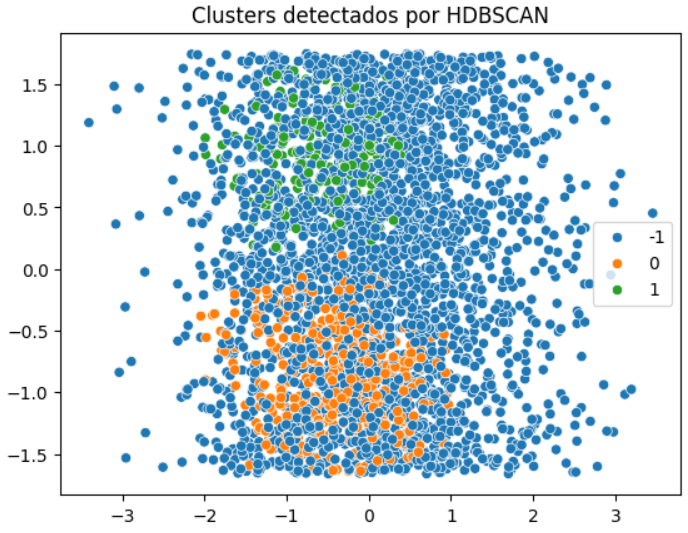

